Imports et configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Configuration visuelle
sns.set_theme(style="whitegrid")
%matplotlib inline

Chargement et nettoyage des données

In [3]:
# Chargement du dataset filtré (Angleterre uniquement)
df = pd.read_csv('England_football_data.csv', sep=';')

# Conversion de la date
df['Date'] = pd.to_datetime(df['Date'])

# Création de la variable cible : Total de buts dans le match
df['TotalGoals'] = df['FTHG'] + df['FTAG']

# Suppression des colonnes inutiles ou qui causent une fuite de données (scores mi-temps, etc.)
# On garde 'HomeTeam', 'AwayTeam' pour le Feature Engineering, on les traitera après.
cols_to_drop_later = ['id', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR']

print(f"Nombre de matchs chargés : {len(df)}")
df[['Date', 'HomeTeam', 'AwayTeam', 'TotalGoals']].head()

Nombre de matchs chargés : 10193


,Date,HomeTeam,AwayTeam,TotalGoals
0,2012-08-18,Arsenal,Sunderland,0.0
1,2012-08-18,Fulham,Norwich,5.0
2,2012-08-18,Newcastle,Tottenham,3.0
3,2012-08-18,QPR,Swansea,5.0
4,2012-08-18,Reading,Stoke,2.0


Feature Engineering : La "Forme" des équipes
On calcule la moyenne des 5 derniers matchs

In [4]:
print("Calcul des indicateurs de forme (Moyennes glissantes sur 5 matchs)...")

#Trier par date pour respecter la chronologie
df = df.sort_values(by='Date')

# Restructurer les données pour avoir une ligne par équipe par match
df_home = df[['id', 'Date', 'HomeTeam', 'FTHG', 'FTAG']].rename(
    columns={'HomeTeam': 'Team', 'FTHG': 'GoalsScored', 'FTAG': 'GoalsConceded'}
)
df_away = df[['id', 'Date', 'AwayTeam', 'FTAG', 'FTHG']].rename(
    columns={'AwayTeam': 'Team', 'FTAG': 'GoalsScored', 'FTHG': 'GoalsConceded'}
)
df_stats = pd.concat([df_home, df_away]).sort_values(by=['Team', 'Date'])

#  Calculer la moyenne glissante (Rolling Window)
# IMPORTANT : on utilise .shift(1) pour ne pas inclure le match actuel dans la moyenne (Data Leakage)
N_MATCHS = 5

df_stats['AvgGoalsScored_Last5'] = df_stats.groupby('Team')['GoalsScored'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)
df_stats['AvgGoalsConceded_Last5'] = df_stats.groupby('Team')['GoalsConceded'].transform(
    lambda x: x.rolling(N_MATCHS, min_periods=1).mean().shift(1)
)

# Remplir les premiers matchs (NaN) par 0
df_stats = df_stats.fillna(0)

# Réintégrer ces stats dans le DataFrame principal
# Pour l'équipe à Domicile
df_stats_home = df_stats.rename(columns={
    'Team': 'HomeTeam',
    'AvgGoalsScored_Last5': 'Home_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Home_Avg_Conceded_Last_5'
})
# Pour l'équipe à l'Extérieur
df_stats_away = df_stats.rename(columns={
    'Team': 'AwayTeam',
    'AvgGoalsScored_Last5': 'Away_Avg_Goals_Last_5',
    'AvgGoalsConceded_Last5': 'Away_Avg_Conceded_Last_5'
})

# Merge sur l'ID du match
df = pd.merge(df, df_stats_home[['id', 'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5']], on='id', how='left')
df = pd.merge(df, df_stats_away[['id', 'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']], on='id', how='left')

# Suppression des doublons éventuels
df = df.drop_duplicates(subset='id')

print("Feature Engineering terminé.")


Calcul des indicateurs de forme (Moyennes glissantes sur 5 matchs)...
Feature Engineering terminé.


Préparation pour le Machine Learning

In [5]:
# Nettoyage final des colonnes
X = df.drop(columns=cols_to_drop_later + ['Date', 'TotalGoals'], errors='ignore')
y = df['TotalGoals']

# Identification automatique des types de colonnes
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Features Numériques ({len(numeric_features)}) : {numeric_features}")
print(f"Features Catégorielles ({len(categorical_features)}) : {categorical_features}")

# 3. Séparation Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Création du Préprocesseur (ColumnTransformer)
# - Numérique : Imputation (médiane) + Standardisation
# - Catégoriel : Imputation (fréquent) + OneHotEncoding
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

Features Numériques (16) : ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'Home_Avg_Goals_Last_5', 'Home_Avg_Conceded_Last_5', 'Away_Avg_Goals_Last_5', 'Away_Avg_Conceded_Last_5']
Features Catégorielles (7) : ['Country', 'League', 'Div', 'Season', 'HomeTeam', 'AwayTeam', 'Referee']


Comparaison des modèles

In [6]:
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
}

results = []

print("Début de l'entraînement des modèles...")
for name, model in models.items():
    # Création du pipeline complet
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    # Entraînement
    clf.fit(X_train, y_train)
    
    # Prédiction et Évaluation
    y_pred = clf.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, r2])
    print(f" -> {name} terminé. R2: {r2:.4f}")

# Affichage du tableau final
results_df = pd.DataFrame(results, columns=["Modèle", "MAE", "R2 Score"]).sort_values(by="R2 Score", ascending=False)
display(results_df)

Début de l'entraînement des modèles...
 -> Ridge Regression terminé. R2: 0.2963
 -> Random Forest terminé. R2: 0.2788
 -> Hist Gradient Boosting terminé. R2: 0.2983


,Modèle,MAE,R2 Score
2,Hist Gradient Boosting,1.102112,0.298307
0,Ridge Regression,1.098078,0.296332
1,Random Forest,1.117181,0.278775


Optimisation du Meilleur Modèle (HGBR)

In [7]:
# On reprend le pipeline avec HistGradientBoostingRegressor
pipeline_hgbr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

# Grille d'hyperparamètres à tester
param_grid = {
    'model__learning_rate': [0.01, 0.1],
    'model__max_iter': [100, 200],
    'model__max_leaf_nodes': [31, 50]
}

print("Lancement du GridSearchCV (Optimisation)...")
grid_search = GridSearchCV(pipeline_hgbr, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score R2 (Cross-Validation) : {grid_search.best_score_:.4f}")

# Modèle final optimisé
best_model = grid_search.best_estimator_
print('model__learning_rate')

Lancement du GridSearchCV (Optimisation)...
Meilleurs paramètres : {'model__learning_rate': 0.01, 'model__max_iter': 200, 'model__max_leaf_nodes': 31}
Meilleur score R2 (Cross-Validation) : 0.2737
model__learning_rate


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# 1. On définit des PLAGES (Distributions) au lieu de listes fixes
param_dist = {
    # loguniform est génial pour le learning_rate : il explore aussi bien les tout petits (0.001) que les moyens (0.1)
    'model__learning_rate': loguniform(0.001, 0.2),
    
    # randint tire un entier au hasard dans la plage (bornes incluses/excluses selon la version)
    'model__max_iter': randint(100, 2000),  # De 100 à 2000 arbres
    
    'model__max_leaf_nodes': randint(2, 60), # De 2 à 60 feuilles (complexité)
    
    # On peut même ajouter la régularisation L2 pour éviter le surapprentissage
    'model__l2_regularization': loguniform(1e-10, 10.0)
}

# 2. Configuration du RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline_hgbr,
    param_distributions=param_dist,
    n_iter=50,       # <--- LA CLÉ : On teste 50 combinaisons aléatoires (Budget temps)
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print(f"Lancement de la recherche aléatoire sur {random_search.n_iter} candidats...")
random_search.fit(X_train, y_train)

print(f"Meilleurs paramètres trouvés : {random_search.best_params_}")
print(f"Meilleur score R2 : {random_search.best_score_:.4f}")

# On récupère le champion
best_model_random = random_search.best_estimator_

Lancement de la recherche aléatoire sur 50 candidats...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres trouvés : {'model__l2_regularization': 1.8155514586475845e-07, 'model__learning_rate': 0.0024004031282525793, 'model__max_iter': 1980, 'model__max_leaf_nodes': 8}
Meilleur score R2 : 0.2886


In [9]:
# Nouvelle grille basée sur les résultats précédents
new_param_grid = {
    # Il a aimé 0.01, on le garde. On peut tester un peu plus grand aussi.
    'model__learning_rate': [0.005, 0.01],
    
    # Il a bloqué à 200 (max), donc on EXPLOSE le plafond.
    # On lui donne 500 et 1000 pour qu'il ait le temps de finir.
    'model__max_iter': [650, 500, 600],
    
    # Il a aimé 31 (le plus petit), on teste encore plus petit (plus simple)
    # et on garde 31 pour comparer.
    'model__max_leaf_nodes': [6, 15]
}

print("Relance du GridSearchCV avec la grille corrigée...")
grid_search_v2 = GridSearchCV(pipeline_hgbr, new_param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search_v2.fit(X_train, y_train)

print(f"Nouveaux meilleurs paramètres : {grid_search_v2.best_params_}")
print(f"Nouveau meilleur score : {grid_search_v2.best_score_:.4f}")

Relance du GridSearchCV avec la grille corrigée...
Nouveaux meilleurs paramètres : {'model__learning_rate': 0.01, 'model__max_iter': 650, 'model__max_leaf_nodes': 6}
Nouveau meilleur score : 0.2897


Analyse importance des features

Calcul de l'importance des features (Permutation Importance)...


/var/folders/h8/s48sjjn17p3d6275jq_2x0nc0000gn/T/ipykernel_67254/2485476108.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result_imp.importances[sorted_idx].T, vert=False, labels=feature_names[sorted_idx])


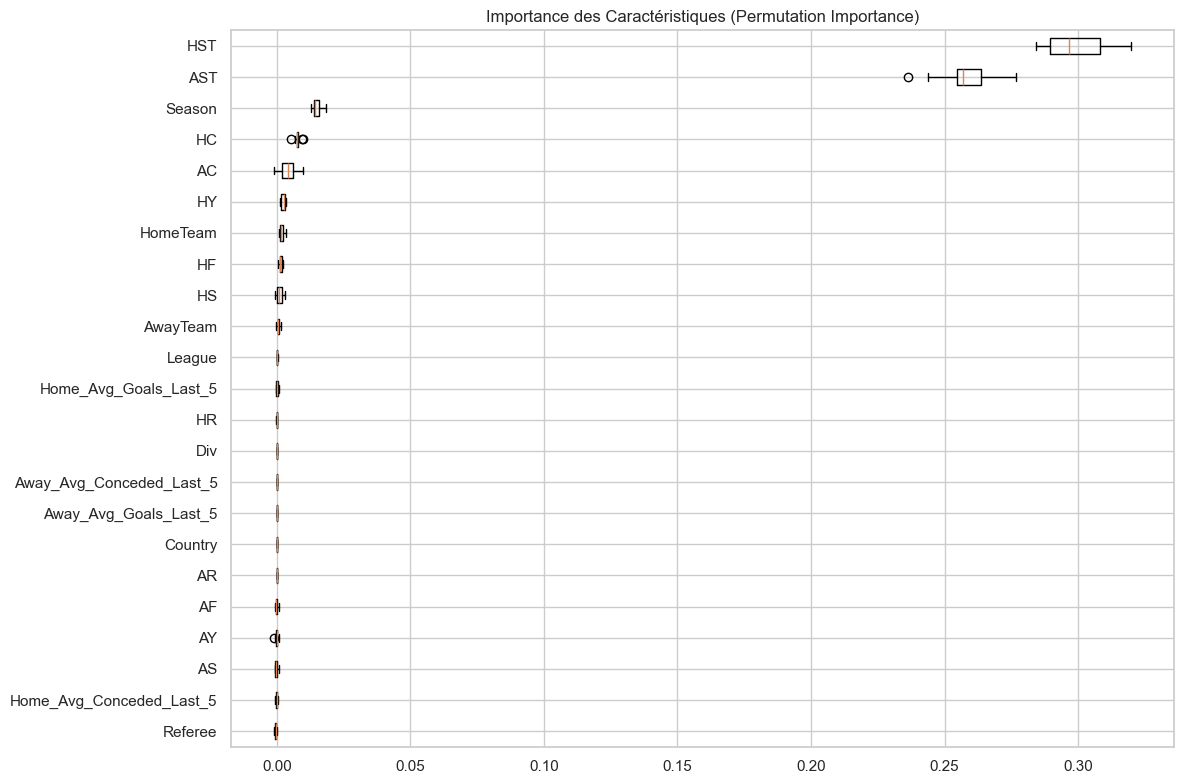

In [10]:
# Note : Pour l'importance des features, on utilise souvent le Random Forest ou une méthode de permutation
# Ici, on utilise la Permutation Importance qui marche sur n'importe quel modèle (y compris le Boosting)
from sklearn.inspection import permutation_importance

print("Calcul de l'importance des features (Permutation Importance)...")
result_imp = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Création du DataFrame pour l'affichage
sorted_idx = result_imp.importances_mean.argsort()
feature_names = X_test.columns

plt.figure(figsize=(12, 8))
plt.boxplot(result_imp.importances[sorted_idx].T, vert=False, labels=feature_names[sorted_idx])
plt.title("Importance des Caractéristiques (Permutation Importance)")
plt.tight_layout()
plt.show()

Analyse des Erreurs (Résidus)

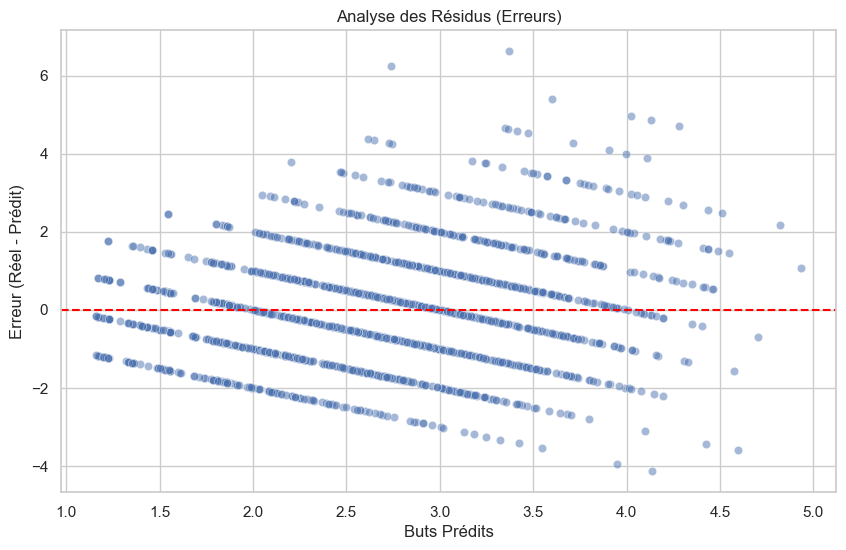

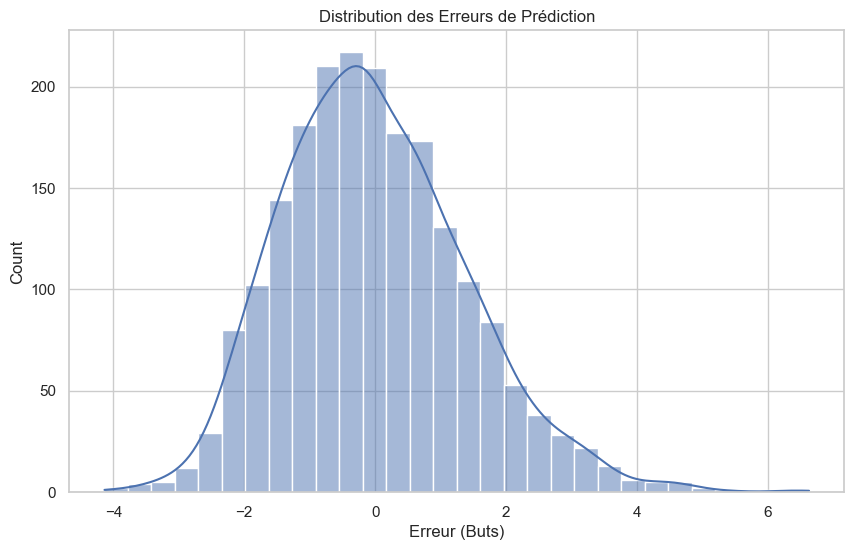

In [11]:
y_pred_final = best_model.predict(X_test)
residuals = y_test - y_pred_final

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Analyse des Résidus (Erreurs)")
plt.xlabel("Buts Prédits")
plt.ylabel("Erreur (Réel - Prédit)")
plt.show()

# Distribution des erreurs
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution des Erreurs de Prédiction")
plt.xlabel("Erreur (Buts)")
plt.show()